# 8. Per-Pollutant Split Models

Every model so far predicts `daily_aqi` directly — but that target is a **max over five
pollutants**, and the error breakdown showed the models handling the two dominant ones very
differently:

| dominant pollutant | test days | MAE | mean bias |
|---|---:|---:|---:|
| Ozone | 546 | 16.33 | +5.45 |
| PM2.5 | 537 | 10.79 | −2.77 |

Opposite biases, and nearly double the error on ozone days. That is the signature of one
function trying to fit two processes. Ozone is photochemical (heat, sunlight, stagnation) and
peaks in July; PM2.5 is mechanical (inversions, smoke, wood burning) and peaks in December.
Their seasonal cycles run in opposite directions.

The alternative: fit a separate model to each pollutant's own AQI, then take the max of the
*predictions*. Each model gets to learn one clean physical relationship instead of a mixture
plus a switch.

Three pollutants get their own model — Ozone, PM2.5 and NO2, the only three that ever set the
daily maximum in LA. Taking the max over predictions rather than actuals keeps this
leak-free.

## Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from model_utils import (load_split, evaluate, diagnostic_plots, metrics,
                         RANDOM_STATE, PLOT_STYLE, PROCESSED, RESULTS)

X_train, y_train, X_test, y_test, meta = load_split()

pol = pd.read_csv(PROCESSED / 'la_daily_aqi_by_pollutant_2016_2025.csv', parse_dates=['date'])
POLLUTANTS = ['aqi_ozone', 'aqi_pm25', 'aqi_no2']

# align the per-pollutant targets to the existing split, by date
tr_tgt = pol.set_index('date').reindex(meta['train_dates'])[POLLUTANTS]
te_tgt = pol.set_index('date').reindex(meta['test_dates'])[POLLUTANTS]

print(f'features: {X_train.shape[1]}  |  train {len(X_train)}  test {len(X_test)}')
print(f'per-pollutant targets aligned: train {tr_tgt.notna().all(axis=1).sum()}, '
      f'test {te_tgt.notna().all(axis=1).sum()}')
print()
print(tr_tgt.describe().round(1).to_string())

features: 37  |  train 2554  test 1095
per-pollutant targets aligned: train 2554, test 1095

       aqi_ozone  aqi_pm25  aqi_no2
count     2554.0    2554.0   2554.0
mean        74.7      69.5     40.8
std         43.6      19.1     15.0
min         23.0      29.0      7.0
25%         41.0      59.0     30.0
50%         54.0      66.0     39.0
75%        101.0      75.0     49.0
max        235.0     250.0    104.0


## The same ensemble recipe, applied per pollutant

To make this a fair comparison against notebook 07, each pollutant gets the identical
treatment: the same three base models with the same hyperparameters, stacked with ridge
weights learned on out-of-fold `TimeSeriesSplit` predictions from the training years only.

The only thing that changes is the target.

In [2]:
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import RidgeCV

def make_svr():
    return Pipeline([('scale', StandardScaler()),
                     ('model', SVR(kernel='rbf', C=300, gamma=0.01, epsilon=10.0))])

def make_mlp():
    return Pipeline([('scale', StandardScaler()),
                     ('model', MLPRegressor(hidden_layer_sizes=(128, 64), alpha=0.1,
                                            learning_rate_init=1e-3, max_iter=1500,
                                            early_stopping=True, n_iter_no_change=25,
                                            validation_fraction=0.15,
                                            random_state=RANDOM_STATE))])

def make_gbr():
    return HistGradientBoostingRegressor(learning_rate=0.03, max_iter=600,
                                         max_leaf_nodes=15, min_samples_leaf=10,
                                         l2_regularization=1.0, early_stopping=False,
                                         random_state=RANDOM_STATE)

BUILDERS = {'SVR': make_svr, 'MLP': make_mlp, 'GBR': make_gbr}
tscv = TimeSeriesSplit(n_splits=5)


def fit_stacked(X_tr, y_tr, X_te):
    """Fit the three base models + a ridge stack; return (test predictions, fitted parts)."""
    oof = {n: np.full(len(X_tr), np.nan) for n in BUILDERS}
    for tr_idx, va_idx in tscv.split(X_tr):
        for name, build_fn in BUILDERS.items():
            m = build_fn().fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx])
            oof[name][va_idx] = m.predict(X_tr.iloc[va_idx])

    M = np.column_stack([oof[n] for n in BUILDERS])
    ok = ~np.isnan(M).any(axis=1)
    stack = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(M[ok], np.asarray(y_tr)[ok])

    fitted = {n: b().fit(X_tr, y_tr) for n, b in BUILDERS.items()}
    te_cols = np.column_stack([fitted[n].predict(X_te) for n in BUILDERS])
    tr_cols = np.column_stack([fitted[n].predict(X_tr) for n in BUILDERS])
    return stack.predict(te_cols), stack.predict(tr_cols), fitted, stack


pol_models, pred_test, pred_train = {}, {}, {}
for col in POLLUTANTS:
    te_p, tr_p, fitted, stack = fit_stacked(X_train, tr_tgt[col], X_test)
    pol_models[col] = (fitted, stack)
    pred_test[col], pred_train[col] = te_p, tr_p
    m = metrics(te_tgt[col], te_p)
    print(f'{col:11} test RMSE {m["rmse"]:6.2f}   R2 {m["r2"]:.3f}   '
          f'(target mean {te_tgt[col].mean():.1f})')

aqi_ozone   test RMSE  16.43   R2 0.870   (target mean 75.8)


aqi_pm25    test RMSE  13.81   R2 0.418   (target mean 63.2)


aqi_no2     test RMSE   7.59   R2 0.572   (target mean 34.8)


## Combining into a daily AQI prediction

The predicted city-wide AQI is the row-wise max of the three predicted pollutant series —
the same rule EPA uses on the actuals, applied to predictions so nothing leaks.

In [3]:
test_matrix  = np.column_stack([pred_test[c]  for c in POLLUTANTS])
train_matrix = np.column_stack([pred_train[c] for c in POLLUTANTS])

combined_test  = test_matrix.max(axis=1)
combined_train = train_matrix.max(axis=1)

direct = np.load(RESULTS / 'ensemble_test_pred.npy')   # notebook 07, single model on daily_aqi

rows = [
    {'approach': 'per-pollutant split (max of 3)', **metrics(y_test, combined_test)},
    {'approach': 'direct ensemble (notebook 07)',  **metrics(y_test, direct)},
]
print(pd.DataFrame(rows).round(3).to_string(index=False))

                      approach   rmse    mae    r2   mape  within_10
per-pollutant split (max of 3) 18.531 12.877 0.789 14.099     55.799
 direct ensemble (notebook 07) 18.336 12.949 0.794 14.778     53.790


## Is the difference real?

Same paired bootstrap as notebook 07 — resample the same days for both predictors so the
shared day-to-day variation cancels.

In [4]:
def rmse_of(y, p):
    return float(np.sqrt(((np.asarray(y, dtype=float) - p) ** 2).mean()))

rng = np.random.default_rng(0)
yt = np.asarray(y_test, dtype=float)
n = len(yt)
idx = [rng.integers(0, n, n) for _ in range(5000)]

diffs = np.array([rmse_of(yt[i], combined_test[i]) - rmse_of(yt[i], direct[i]) for i in idx])
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f'split minus direct: {rmse_of(yt, combined_test) - rmse_of(yt, direct):+.3f} RMSE')
print(f'95% CI: [{lo:+.3f}, {hi:+.3f}]')
print(f'P(split better) = {(diffs < 0).mean():.3f}')
print('significant' if hi < 0 or lo > 0 else 'NOT significant — the two are indistinguishable')

split minus direct: +0.195 RMSE
95% CI: [-0.101, +0.489]
P(split better) = 0.098
NOT significant — the two are indistinguishable


## Did it fix the ozone/PM2.5 bias split?

The original motivation was that the direct model carried opposite biases on ozone days and
PM2.5 days. Whether the split fixes *that* matters more than the headline RMSE.

In [5]:
official = pd.read_csv(PROCESSED / 'la_daily_aqi_5pollutants_v2_2016_2025.csv',
                       parse_dates=['date'])[['date', 'dominant_pollutant']]
dom = official.set_index('date').reindex(meta['test_dates'])['dominant_pollutant'].values

cmp_rows = []
for label, pred in [('direct ensemble', direct), ('per-pollutant split', combined_test)]:
    for p in ['Ozone', 'PM2.5']:
        m = dom == p
        cmp_rows.append({'model': label, 'dominant': p, 'n': int(m.sum()),
                         'MAE': np.mean(np.abs(yt[m] - pred[m])),
                         'bias': np.mean(pred[m] - yt[m])})
print(pd.DataFrame(cmp_rows).round(2).to_string(index=False))

print('\nExtreme days (actual AQI > 150):')
hi_mask = yt > 150
for label, pred in [('direct ensemble', direct), ('per-pollutant split', combined_test)]:
    print(f'  {label:22} MAE {np.mean(np.abs(yt[hi_mask]-pred[hi_mask])):6.2f}   '
          f'bias {np.mean(pred[hi_mask]-yt[hi_mask]):+6.2f}')

              model dominant   n   MAE  bias
    direct ensemble    Ozone 546 16.08 -4.74
    direct ensemble    PM2.5 537  9.87  2.53
per-pollutant split    Ozone 546 16.59 -7.89
per-pollutant split    PM2.5 537  9.22  0.56

Extreme days (actual AQI > 150):
  direct ensemble        MAE  30.27   bias -28.15
  per-pollutant split    MAE  32.49   bias -31.01


## Scoring it alongside the others

In [6]:
MODEL_NAME = 'Pollutant Split'

class PollutantSplitModel:
    """Per-pollutant stacked ensembles, combined by taking the max of predictions."""
    def __init__(self, models, pollutants):
        self.models, self.pollutants = models, pollutants

    def predict(self, X):
        cols = []
        for c in self.pollutants:
            fitted, stack = self.models[c]
            cols.append(stack.predict(np.column_stack([m.predict(X) for m in fitted.values()])))
        return np.column_stack(cols).max(axis=1)

best = PollutantSplitModel(pol_models, POLLUTANTS)

result = evaluate(MODEL_NAME, best, X_train, y_train, X_test, y_test,
                  params={'pollutants': POLLUTANTS,
                          'per_pollutant_model': 'stacked SVR+MLP+GBR',
                          'combination': 'row-wise max of predictions'},
                  notes='One stacked ensemble per pollutant, combined by max')

=== Pollutant Split ===
metric           train      test
RMSE            13.062    18.531
MAE              8.952    12.877
R2               0.875     0.789
MAPE %           9.468    14.099
within10 %      70.164    55.799

overfit gap (test RMSE - train RMSE): +5.469
saved -> models/results/pollutant_split.json


## Diagnostics

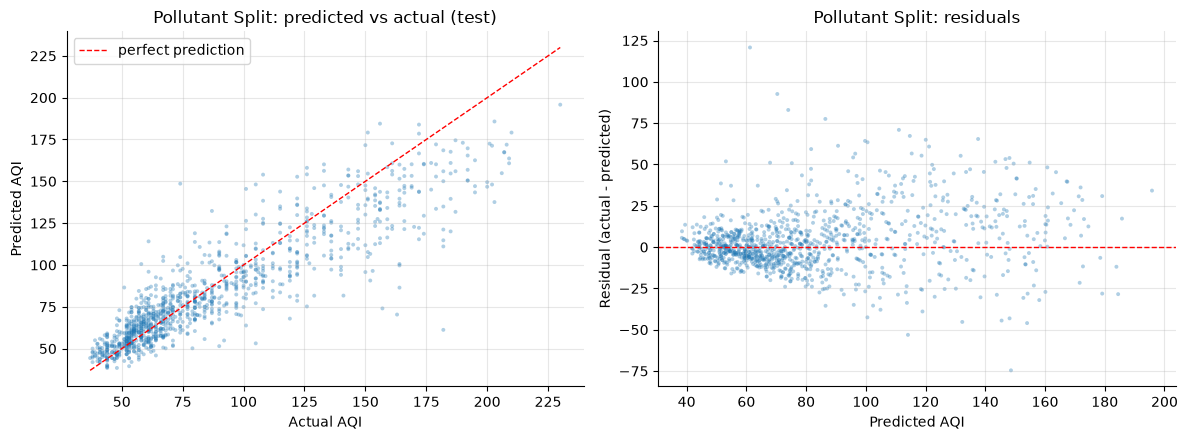

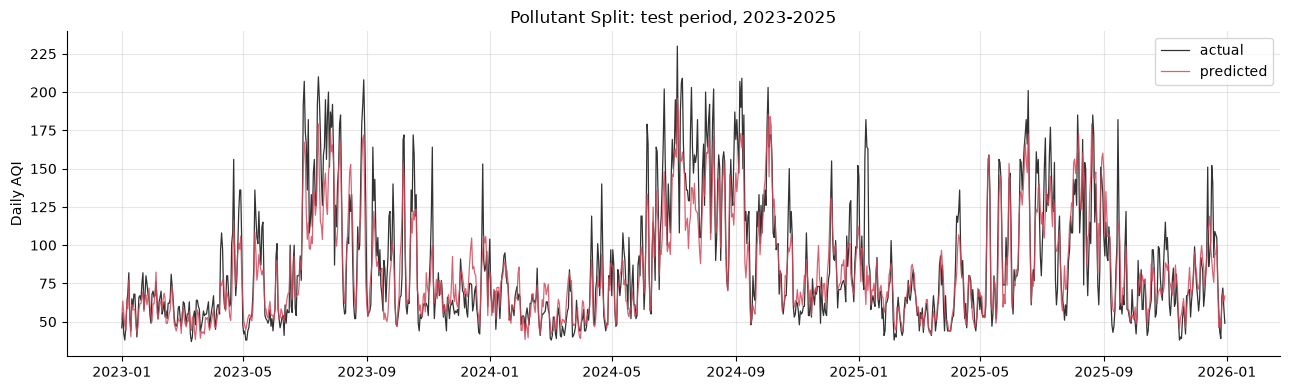

In [7]:
diagnostic_plots(MODEL_NAME, y_test, best.predict(X_test), meta['test_dates'])

## What this told us

**The split does not improve the headline RMSE — and that is not the interesting part.**

| metric | direct ensemble | per-pollutant split | |
|---|---:|---:|---|
| RMSE | **18.336** | 18.531 | worse |
| MAE | 12.949 | **12.877** | better |
| MAPE % | 14.778 | **14.099** | better |
| **within 10 AQI** | 53.8% | **55.8%** | **better — best in the project** |
| R² | **0.794** | 0.789 | worse |

The paired bootstrap puts the RMSE difference at +0.195 with a CI of [−0.101, +0.489], so the
two approaches are statistically indistinguishable on RMSE. But the split is better on MAE,
MAPE and within-10, and worse on RMSE and R². That pattern has a specific meaning: **better on
typical days, worse on extreme ones.** RMSE squares the errors, so it is dominated by the
tails; MAE and within-10 describe the middle.

The extreme-day numbers confirm it — on days above AQI 150 the split's MAE is 32.49 against
the direct model's 30.27, with bias −31.0 against −28.2.

**Why taking the max of predictions makes extremes worse.** Each pollutant model shrinks its
predictions toward its own mean, as any squared-error model does. Taking the maximum of
several already-shrunken predictions produces something *more* shrunken than a single model
predicting the max directly, because the max operator cannot recover a peak that none of its
inputs contains. This is a real structural cost of the decomposition, and it is the opposite
of what I expected going in.

### The finding that actually matters

Fitting the pollutants separately exposed something the blended target completely hides:

| pollutant | test RMSE | **test R²** |
|---|---:|---:|
| Ozone | 16.43 | **0.870** |
| NO2 | 7.59 | 0.572 |
| PM2.5 | 13.81 | **0.418** |

**Ozone is 87% explained by weather. PM2.5 is only 42%.**

That is a large and physically sensible gap. Ozone is manufactured in the atmosphere by heat
and sunlight acting on precursors, so weather is very nearly the whole story. PM2.5 is emitted
— wildfire smoke, wood burning, brake and tire dust, cooking — and weather only modulates how
much of it disperses. No amount of weather data will predict a fire.

The project's headline "weather explains 79% of daily AQI" is therefore an average across two
very different regimes. The honest version is: **weather explains ozone very well and PM2.5
poorly**, and since PM2.5 sets the daily maximum on 51% of days, it is the binding constraint
on the whole model.

That reframes the roadmap. Better weather features (boundary-layer height, inversion strength)
should lift the PM2.5 model, since dispersion is exactly what they measure. But closing the
gap properly needs a *non-weather* input — a smoke or fire indicator — because a large part of
LA's PM2.5 variance simply is not meteorological.